## Task 4(a): Take a grayscale image of size 512x512, add some Gaussian Noise & apply 4th order Butterworth & Gaussian Low Pass Filter to analyze their performance quantitatively

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Function for Butterworth Low Pass Filter

In [2]:
def apply_butterworth_filter(image, order, cutoff_frequency):
    height, width = image.shape
    butterworth_filter = np.zeros((height, width), dtype=np.float32)

    for u in range(height):
        for v in range(width):
            D = np.sqrt((u-height/2)**2 + (v- width/2)**2)
            butterworth_filter[u,v] = 1/(1+(D/cutoff_frequency)**(2*order))
    filtered_image = image * butterworth_filter
    filtered_image = np.fft.ifft2(np.fft.ifftshift(filtered_image))
    return np.abs(filtered_image)

## Function for Gaussian Low Pass Filter

In [4]:
def apply_gaussian_filter(image, cutoff_frequency):
    height, width = image.shape
    gaussian_filter = np.zeros((height,width), dtype=np.float32)

    for u in range(height):
        for v in range(width):
            D = np.sqrt((u-height/2)**2 + (v-width/2)**2)
            gaussian_filter[u, v] = np.exp(-(D**2)/(2* (cutoff_frequency)**2))

    filtered_image = image * gaussian_filter
    filtered_image = np.fft.ifft2(np.fft.ifftshift(filtered_image))
    return np.abs(filtered_image)

## Loading the image

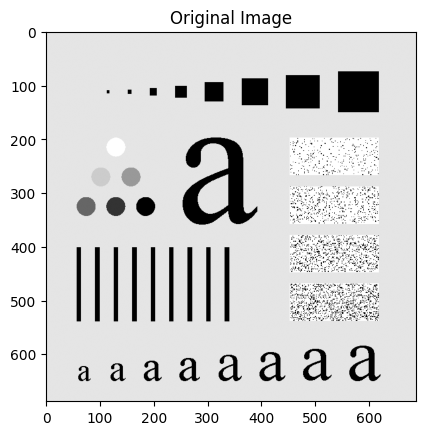

In [5]:
character_pattern_image = cv2.imread("./Characters Test Pattern 688x688 (1).tif", 0)
plt.imshow(character_pattern_image, cmap='gray')
plt.title("Original Image")
plt.show()


## Adding Gaussian Noise

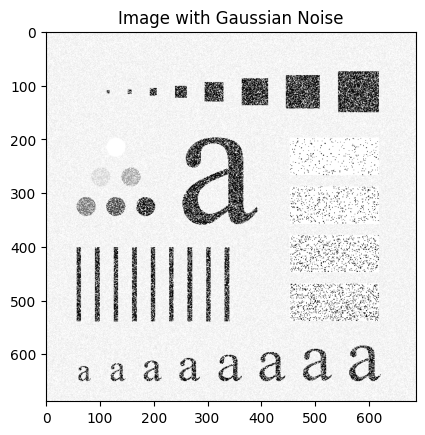

In [7]:
gaussian_noise = np.random.normal(7, 13, character_pattern_image.shape).astype(np.uint8)
noisy_character_image = cv2.add(character_pattern_image, gaussian_noise)
plt.imshow(noisy_character_image, cmap='gray')
plt.title("Image with Gaussian Noise")
plt.show()

## Applying FFT (Fast Fourier Transform)

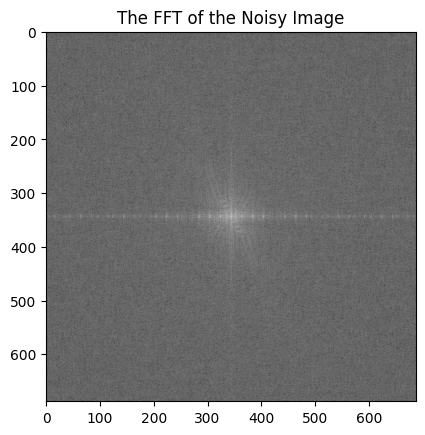

In [10]:
noisy_image_fft = np.fft.fftshift(np.fft.fft2(noisy_character_image))
plt.imshow(np.log(np.abs(noisy_image_fft)), cmap='gray')
plt.title("The FFT of the Noisy Image")
plt.show()

## Applying Butterworth Filter

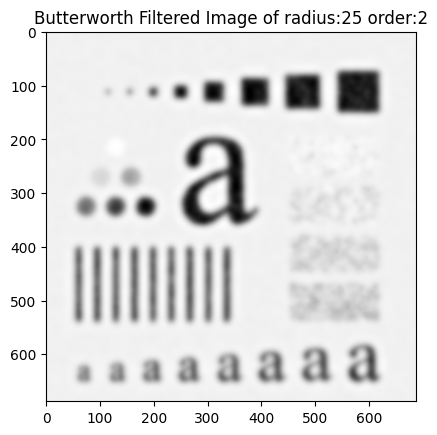

In [14]:
order, radius = 2, 25
butter_worth_filtered_image = apply_butterworth_filter(noisy_image_fft, order, radius)
plt.imshow(butter_worth_filtered_image, cmap='gray')
plt.title(f"Butterworth Filtered Image of radius:{radius} order:{order}")
plt.show()

## Applying Gaussian Low Pass Filter

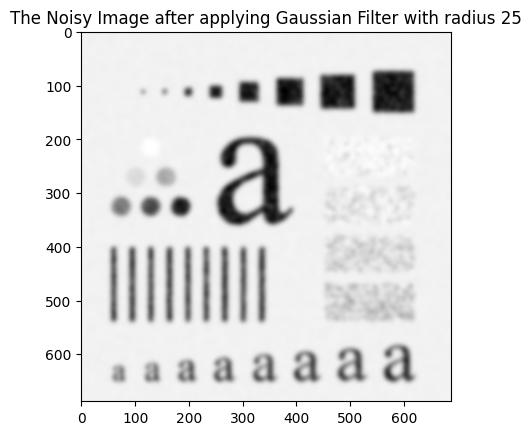

In [15]:
radius = 25
gaussian_filtered_image = apply_gaussian_filter(noisy_image_fft, radius)
plt.imshow(gaussian_filtered_image, cmap = "gray")
plt.title("The Noisy Image after applying Gaussian Filter with radius 25")
plt.show()